<a href="https://colab.research.google.com/github/benniella/Ml-learning/blob/main/Customer_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
import re

In [ ]:
import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
analyzer = SentimentIntensityAnalyzer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


In [ ]:
df=pd.read_csv('reviews.csv')
df.head()

,CustomerID,ReviewText,ServiceType,Rating
0,CUST_0001,Our resort vacation was amazing. The view was ...,Resort,4
1,CUST_0002,"The hotel stay was excellent, and the staff we...",Hotel,4
2,CUST_0003,"The resort had fantastic amenities, and we enj...",Hotel,1
3,CUST_0004,"The resort had fantastic amenities, and we enj...",Hotel,3
4,CUST_0005,"The car rental process was smooth, and the veh...",Hotel,3


In [ ]:
def preprocess_text(text):
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize
    words = word_tokenize(text)
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    # Lemmatize words
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)


In [ ]:
analyzer = SentimentIntensityAnalyzer()



In [ ]:
df['CleanedReviewText'] = df['ReviewText'].apply(preprocess_text)


In [ ]:
df['SentimentScore'] = df['CleanedReviewText'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
df['Sentiment'] = df['SentimentScore'].apply(lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))

df.head()

,CustomerID,ReviewText,ServiceType,Rating,CleanedReviewText,SentimentScore,Sentiment
0,CUST_0001,Our resort vacation was amazing. The view was ...,Resort,4,resort vacation amazing view stunning service ...,0.7506,Positive
1,CUST_0002,"The hotel stay was excellent, and the staff we...",Hotel,4,hotel stay excellent staff friendly,0.7845,Positive
2,CUST_0003,"The resort had fantastic amenities, and we enj...",Hotel,1,resort fantastic amenity enjoyed stay,0.7845,Positive
3,CUST_0004,"The resort had fantastic amenities, and we enj...",Hotel,3,resort fantastic amenity enjoyed stay,0.7845,Positive
4,CUST_0005,"The car rental process was smooth, and the veh...",Hotel,3,car rental process smooth vehicle great condition,0.6249,Positive


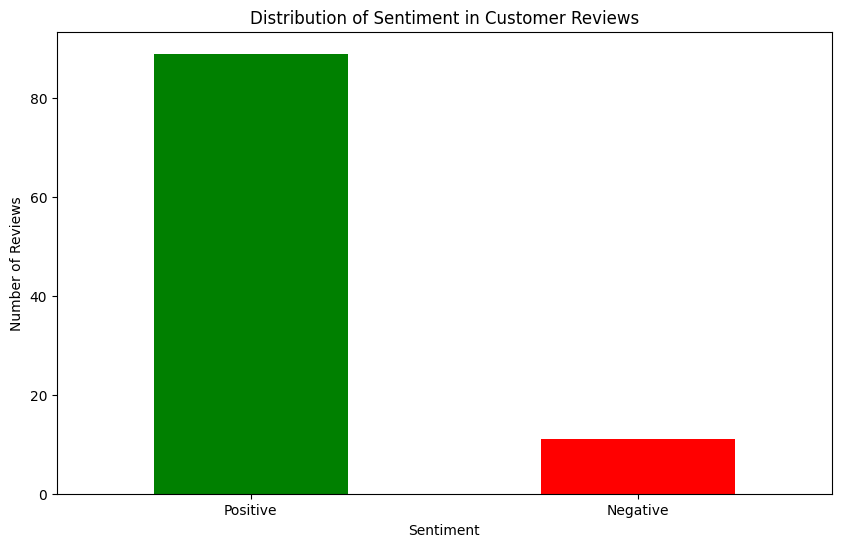

In [ ]:
plt.figure(figsize=(10, 6))
df['Sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Distribution of Sentiment in Customer Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

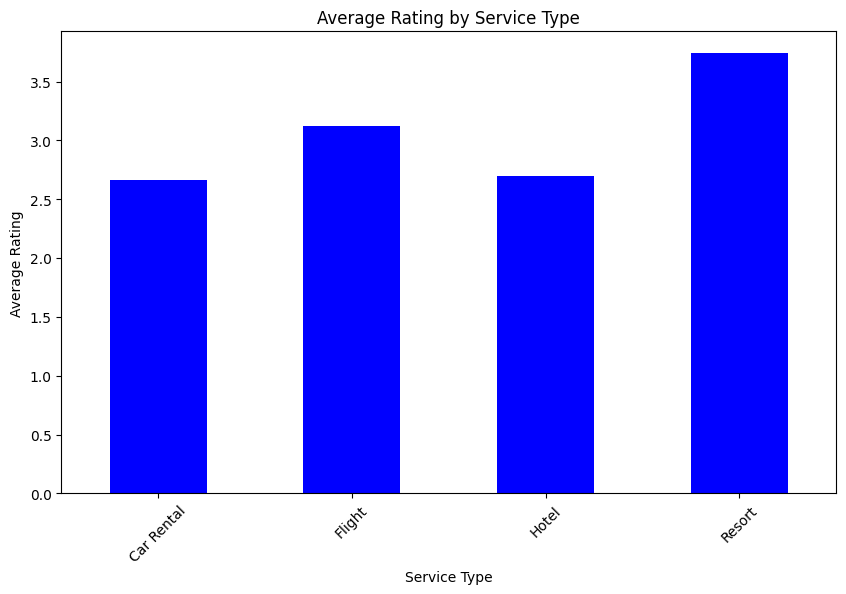

In [ ]:
plt.figure(figsize=(10, 6))
df.groupby('ServiceType')['Rating'].mean().plot(kind='bar', color='blue')
plt.title('Average Rating by Service Type')
plt.xlabel('Service Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.head()

,CustomerID,ReviewText,ServiceType,Rating,CleanedReviewText,SentimentScore,Sentiment
0,CUST_0001,Our resort vacation was amazing. The view was ...,Resort,4,resort vacation amazing view stunning service ...,0.7506,Positive
1,CUST_0002,"The hotel stay was excellent, and the staff we...",Hotel,4,hotel stay excellent staff friendly,0.7845,Positive
2,CUST_0003,"The resort had fantastic amenities, and we enj...",Hotel,1,resort fantastic amenity enjoyed stay,0.7845,Positive
3,CUST_0004,"The resort had fantastic amenities, and we enj...",Hotel,3,resort fantastic amenity enjoyed stay,0.7845,Positive
4,CUST_0005,"The car rental process was smooth, and the veh...",Hotel,3,car rental process smooth vehicle great condition,0.6249,Positive
